# Labrador Sea seasonal-mean maps — CESM3 preindustrial development

Compares CAM h0a monthly output for:
* **388** — `b.e30_alpha09e_m.B1850C_MTso_Gris_Marbl.ne30_t233_wgx3.388` — Lab Sea stays frozen
* **377** — `b.e30_alpha09d_m.B1850C_MTso_Gris_Marbl.ne30_t233_wgx3.377` — Lab Sea melts

Both start from the same slightly frozen state.

Produces side-by-side maps of the two cases for the following fields, averaged over **JFM** and **JAS** across the overlapping years of the two runs:

* `ICEFRAC` — sea-ice fraction
* `SHFLX`, `LHFLX` — sensible / latent heat flux (up)
* `TS` — surface temperature
* `PRECT` — total precipitation (GPCP obs overlaid as a third panel)
* `CLDLOW` — low cloud fraction
* `FSNS`, `FLNS`, `FSDS` — net-solar, net-longwave, downwelling-solar at surface
* `RESSURF` — **derived** net downward surface energy flux = `FSNS − FLNS − SHFLX − LHFLX`

All logic lives in `labsea_utils.py` — this notebook is just orchestration.

In [ ]:
%load_ext autoreload
%autoreload 2

import importlib
import labsea_utils as lsu
importlib.reload(lsu)

import matplotlib.pyplot as plt
from dask.distributed import Client
from dask_jobqueue import PBSCluster

RUNS   = ["388", "377"]
# Fields to plot — start from the module's VAR_LIST so any new entry there
# (e.g. RESSURF) is picked up automatically.  Override this list explicitly if
# you want to restrict the notebook to a subset for a fast run.
VARS   = list(lsu.VAR_LIST)     # ICEFRAC, SHFLX, LHFLX, TS, PRECT, CLDLOW,
                                # FSNS, FLNS, FSDS, RESSURF
SEASONS = ["JFM", "JAS"]
FIG_DIR = "./figs"

# Restrict the map climatology to the overlap of the two runs
# so the same set of years drives both means.
yr0, yr1 = lsu.overlap_years(RUNS)
# Optional: skip the first 5 years as spin-up.  Turn this off by setting SPINUP = 0.
SPINUP = 5
yr0 = yr0 + SPINUP
print(f"Averaging years {yr0}-{yr1}  (overlap of runs {RUNS} with {SPINUP}-yr spinup skipped)")
print("Variables:", VARS)

In [11]:
cluster = PBSCluster(
    account="P03010039",
    interface="ext",
    walltime="12:00:00",
    queue="main",   
    cores=4,
    memory="32GB",
    processes=4,      # one process per core (safe default)cesm2
    local_directory="/glade/derecho/scratch/rneale/dask-temp",
    log_directory="/glade/derecho/scratch/rneale/dask-logs"
)

cluster.scale(jobs=32)
client = Client(cluster)

client

/glade/work/rneale/conda-envs/neale_vproc2/lib/python3.14/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 44197 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: dask_jobqueue.PBSCluster
Dashboard: /node/crhtc44.hpc.ucar.edu/6809/proxy/44197/status,
Dashboard: /node/crhtc44.hpc.ucar.edu/6809/proxy/44197/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://128.117.208.94:36807,Workers: 0
Dashboard: /node/crhtc44.hpc.ucar.edu/6809/proxy/44197/status,Total threads: 0
Started: Just now,Total memory: 0 B


In [12]:
# Open the two runs (only the variables we need).
vars_needed = VARS
datasets = {}
for r in RUNS:
    print(f"Opening run {r} ...")
    datasets[r] = lsu.load_run(r, vars_needed, year_range=(yr0, yr1))
    print(f"  {r}: {datasets[r].sizes.get('time', '?')} monthly records")

Opening run 388 ...
  388: 468 monthly records
Opening run 377 ...
  377: 468 monthly records


In [ ]:
# Compute (var, season) -> {run_id: 2D field} climatologies.
clim = {}
for var in VARS:
    for season in SEASONS:
        fields = {}
        for r in RUNS:
            fields[r] = lsu.seasonal_mean(datasets[r], var, season,
                                          year_range=(yr0, yr1))
            fields[r].load()
        clim[(var, season)] = fields
        print(f"  computed {var:8s} {season}")

# GPCP overlay for PRECT.  Full record, treated as a third panel.
gpcp = lsu.load_gpcp()
for season in SEASONS:
    obs_field = lsu.obs_seasonal_mean(gpcp, "PRECT", season).load()
    clim[("PRECT", season)]["GPCP"] = obs_field
    print(f"  added GPCP PRECT {season}")

  saved ./figs/map_ICEFRAC_JFM_LabSea.png


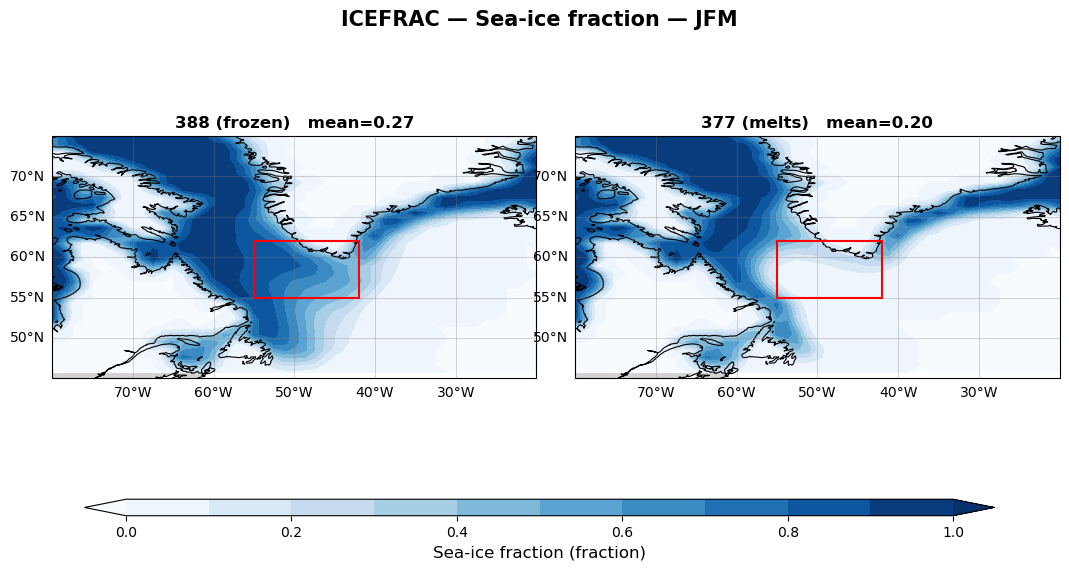

  saved ./figs/map_ICEFRAC_JAS_LabSea.png


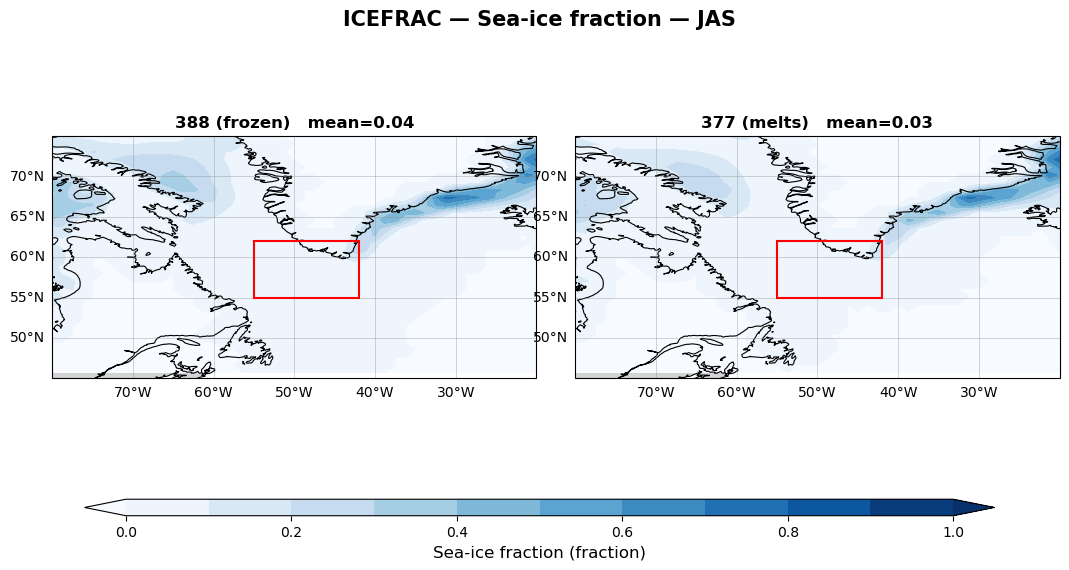

  saved ./figs/map_SHFLX_JFM_LabSea.png


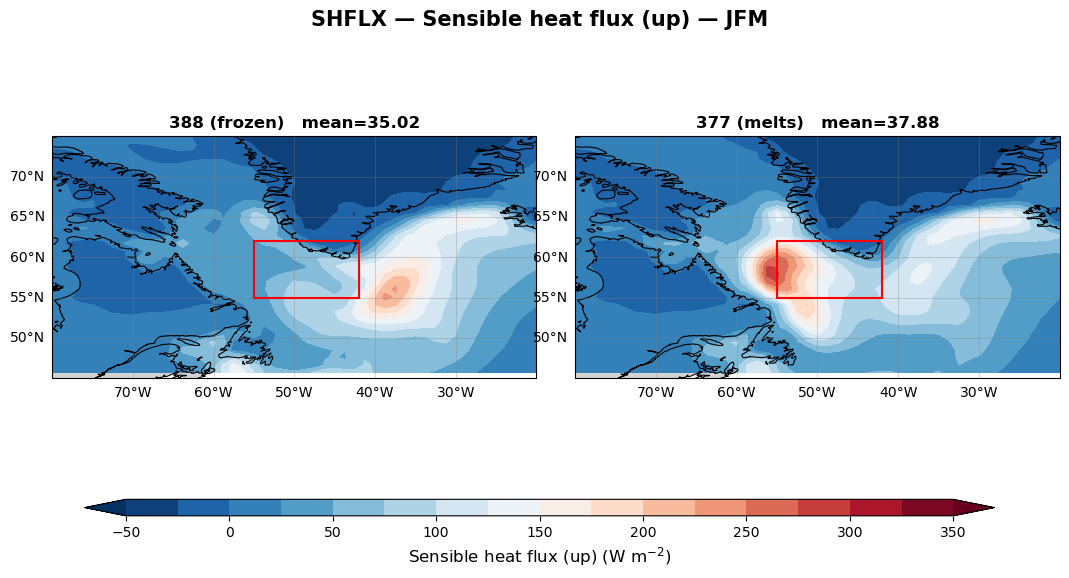

  saved ./figs/map_SHFLX_JAS_LabSea.png


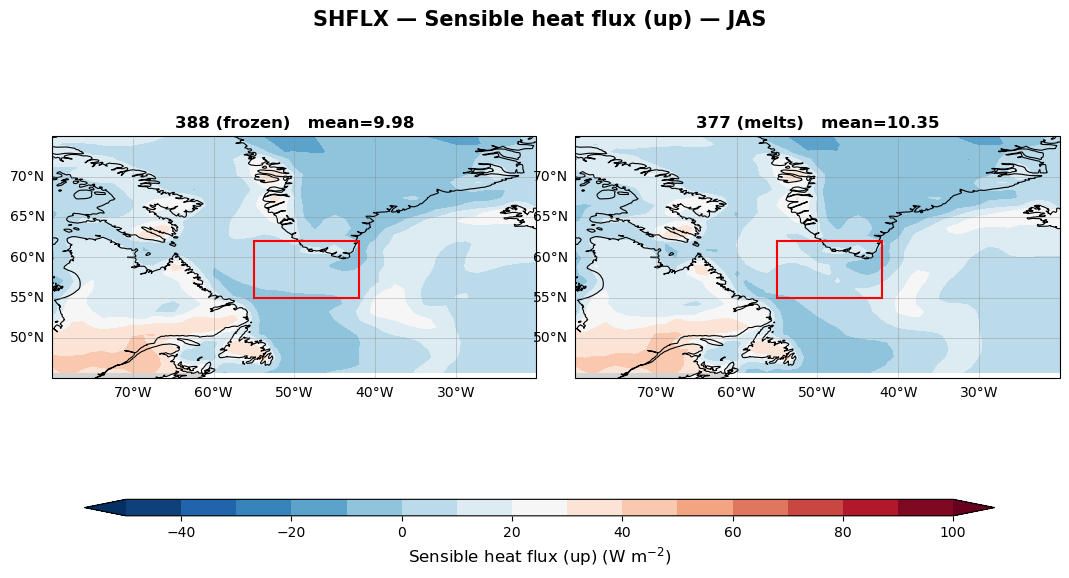

  saved ./figs/map_LHFLX_JFM_LabSea.png


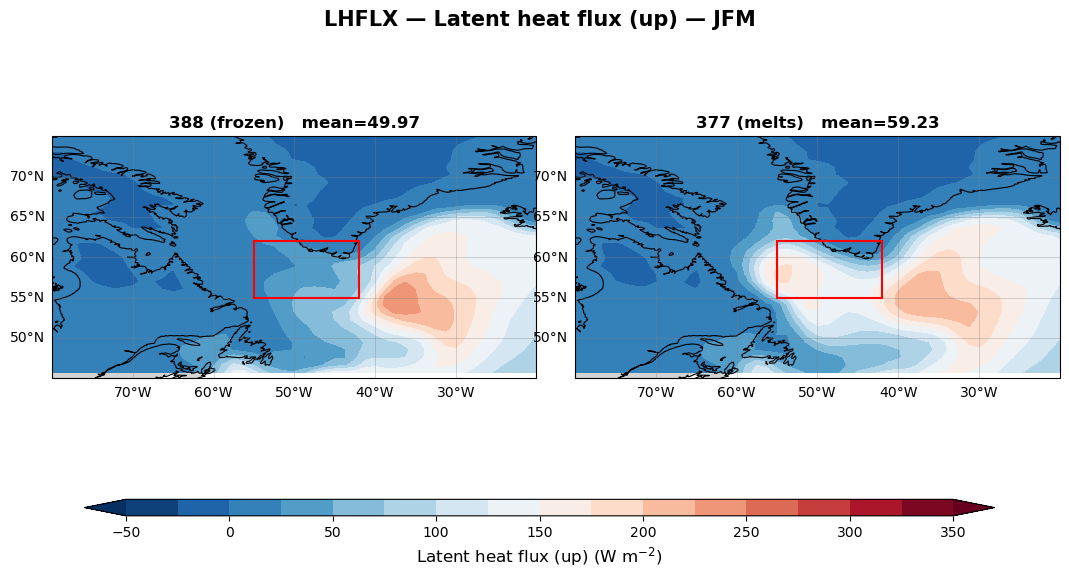

  saved ./figs/map_LHFLX_JAS_LabSea.png


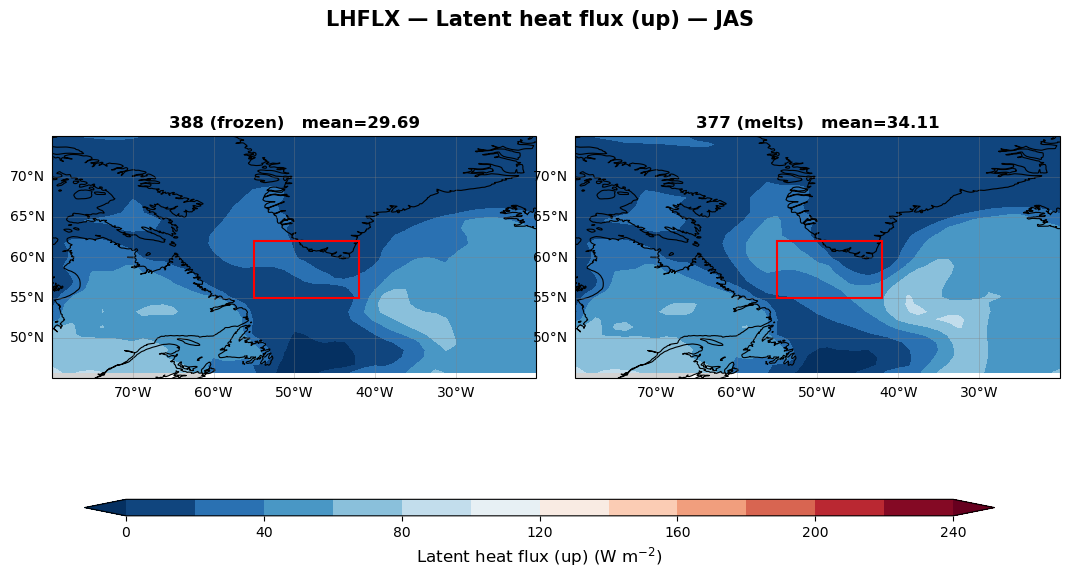

  saved ./figs/map_TS_JFM_LabSea.png


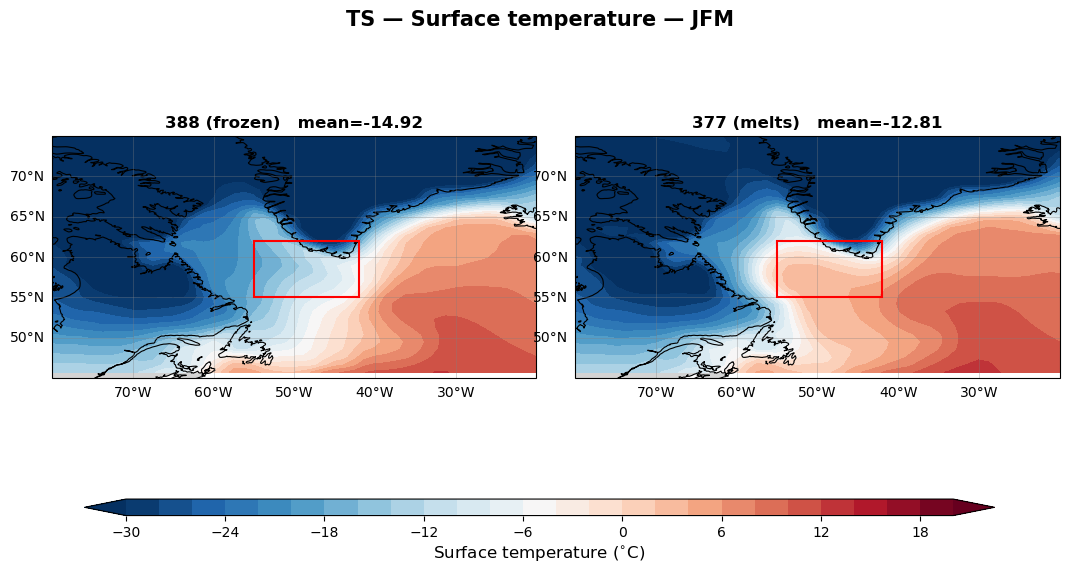

  saved ./figs/map_TS_JAS_LabSea.png


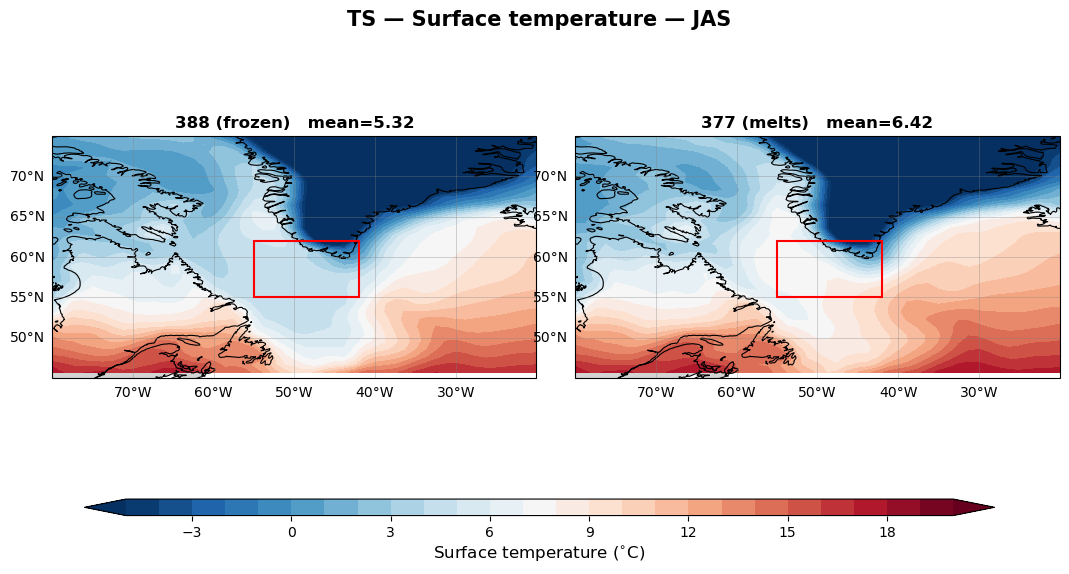

  saved ./figs/map_PRECT_JFM_LabSea.png


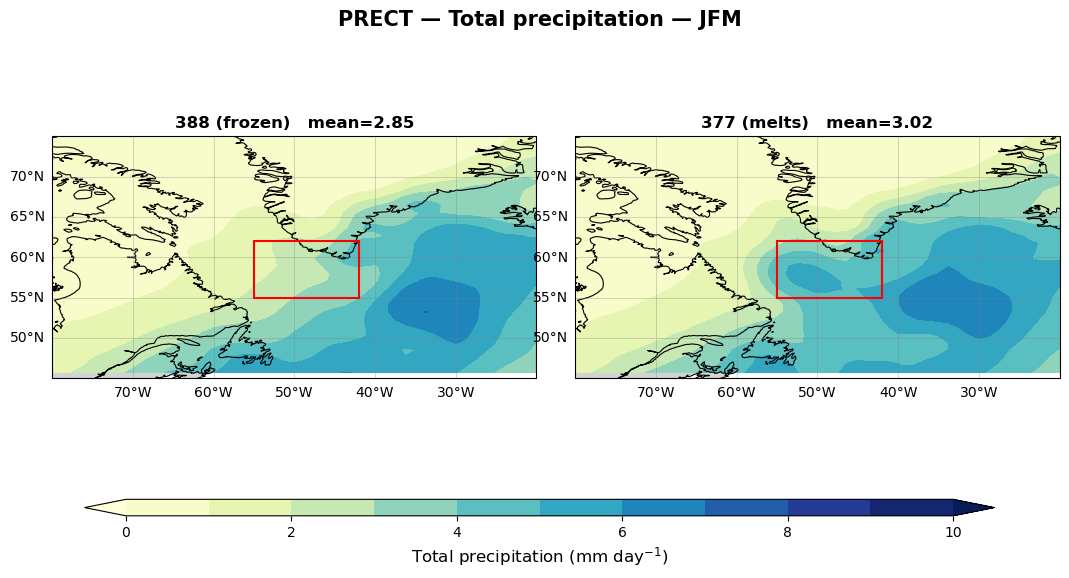

  saved ./figs/map_PRECT_JAS_LabSea.png


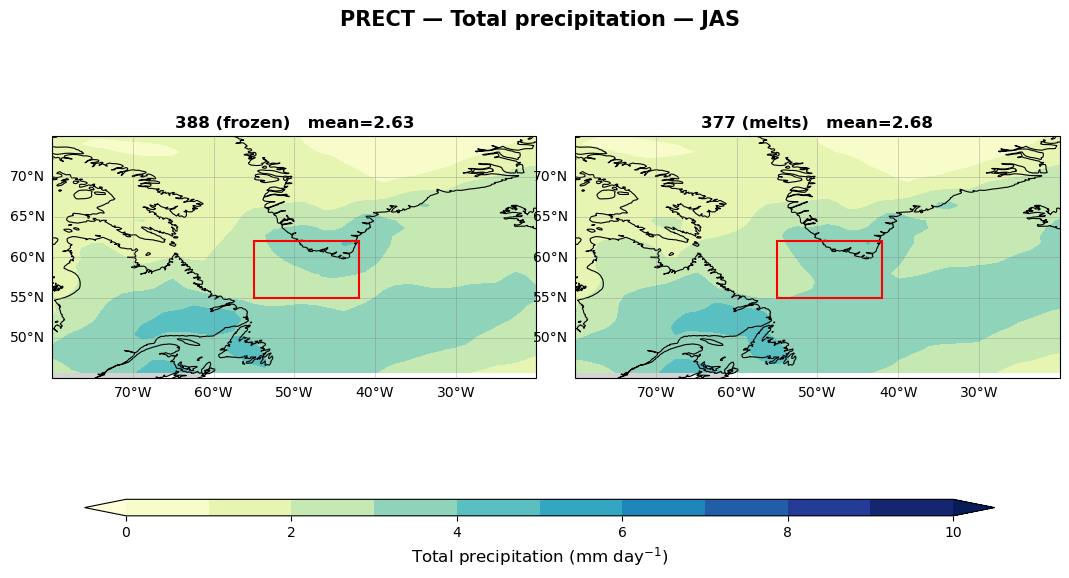

  saved ./figs/map_CLDLOW_JFM_LabSea.png


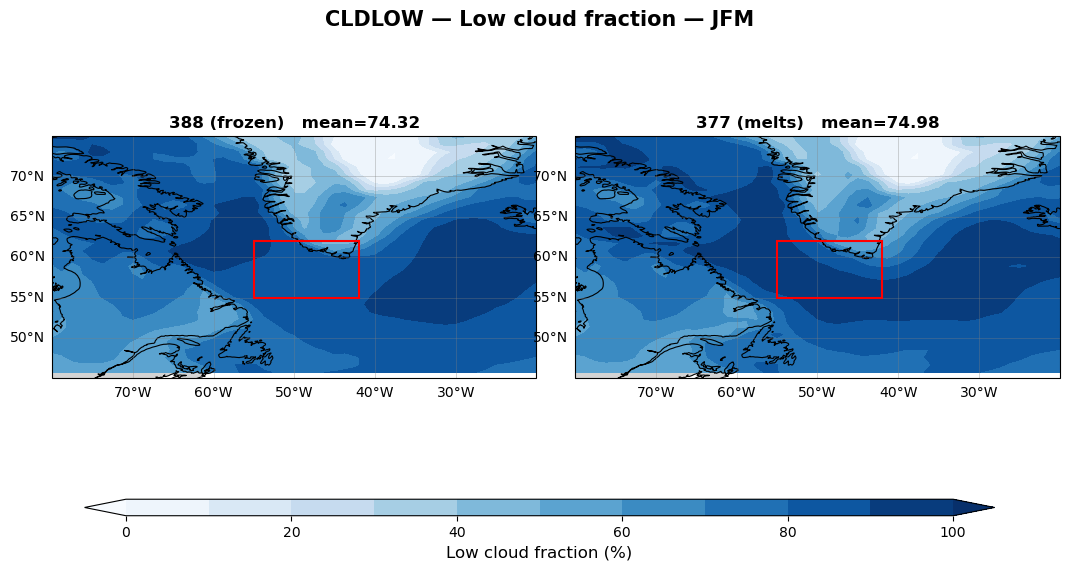

  saved ./figs/map_CLDLOW_JAS_LabSea.png


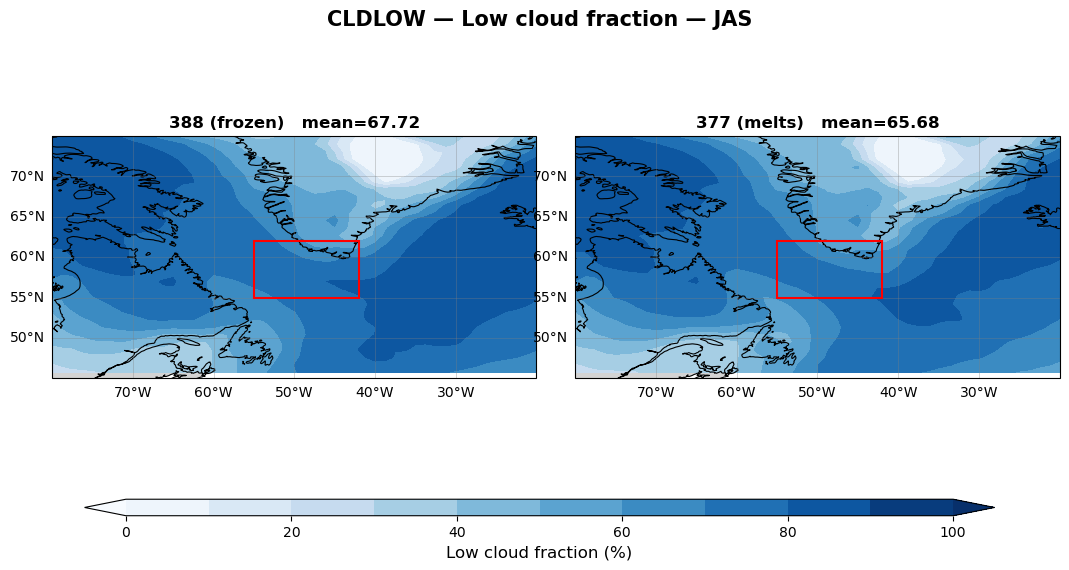

  saved ./figs/map_FSNS_JFM_LabSea.png


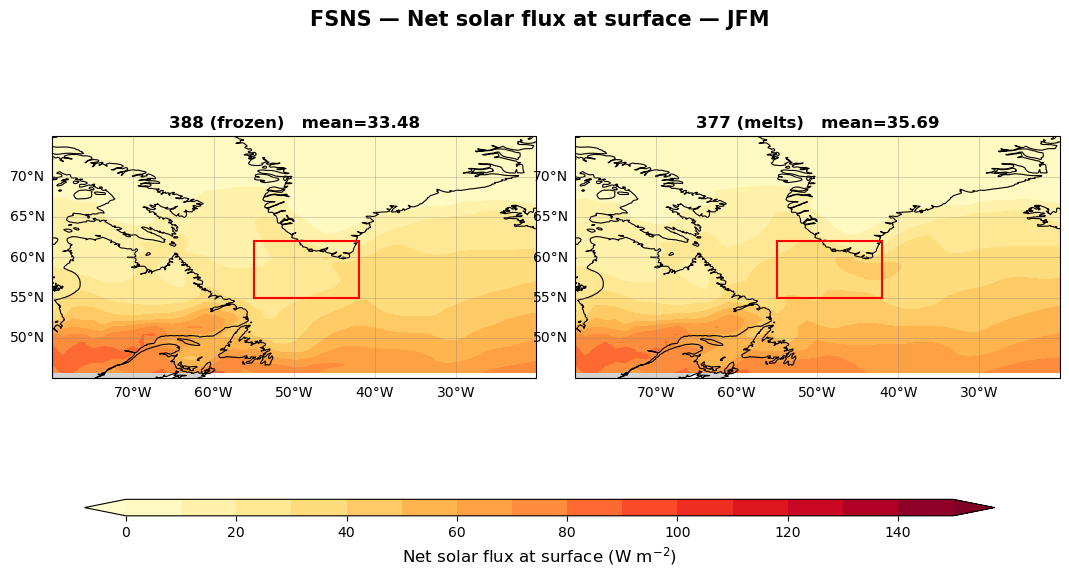

  saved ./figs/map_FSNS_JAS_LabSea.png


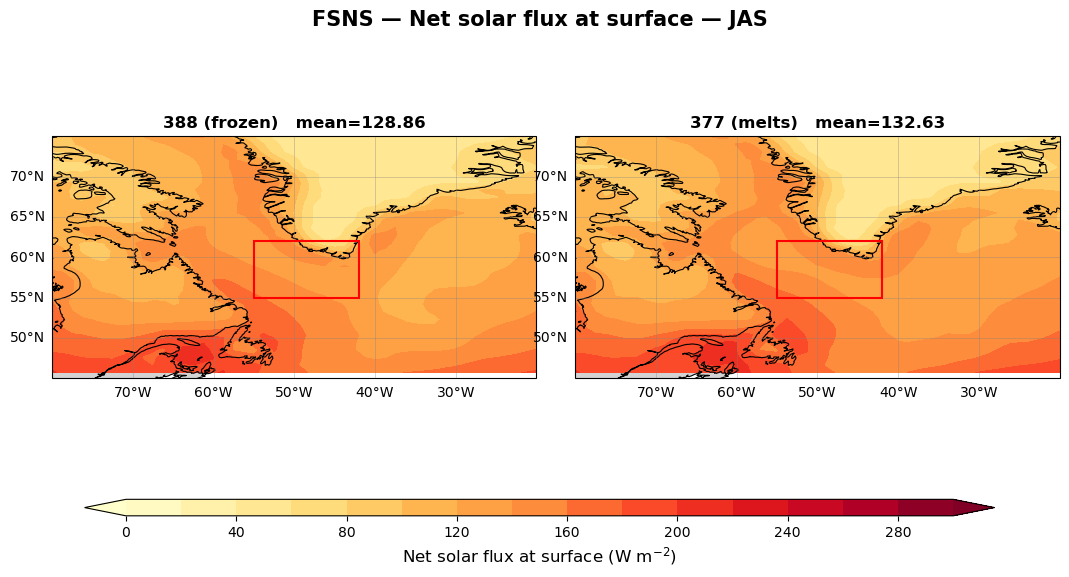

  saved ./figs/map_FLNS_JFM_LabSea.png


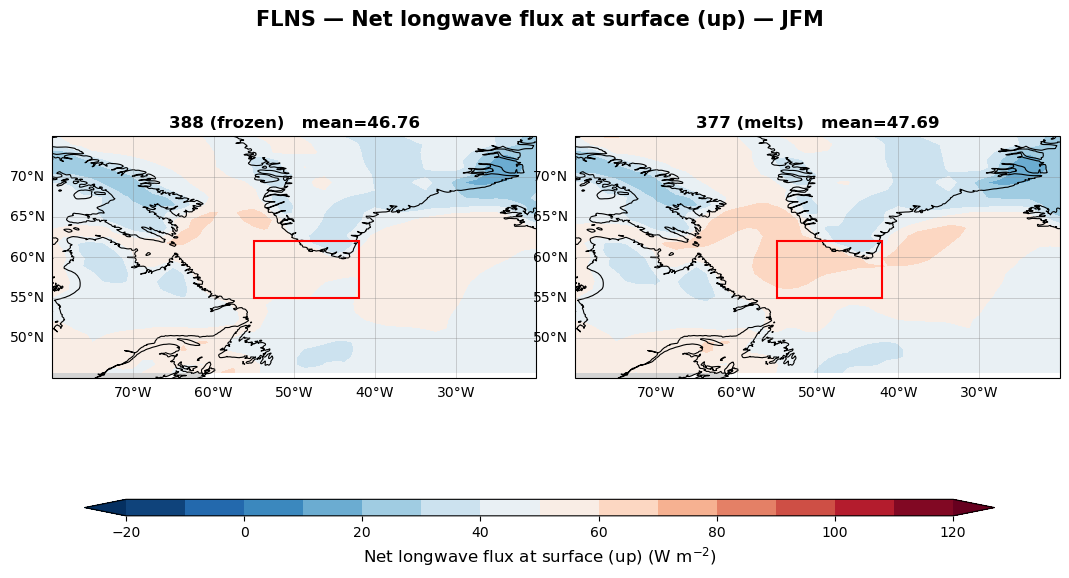

  saved ./figs/map_FLNS_JAS_LabSea.png


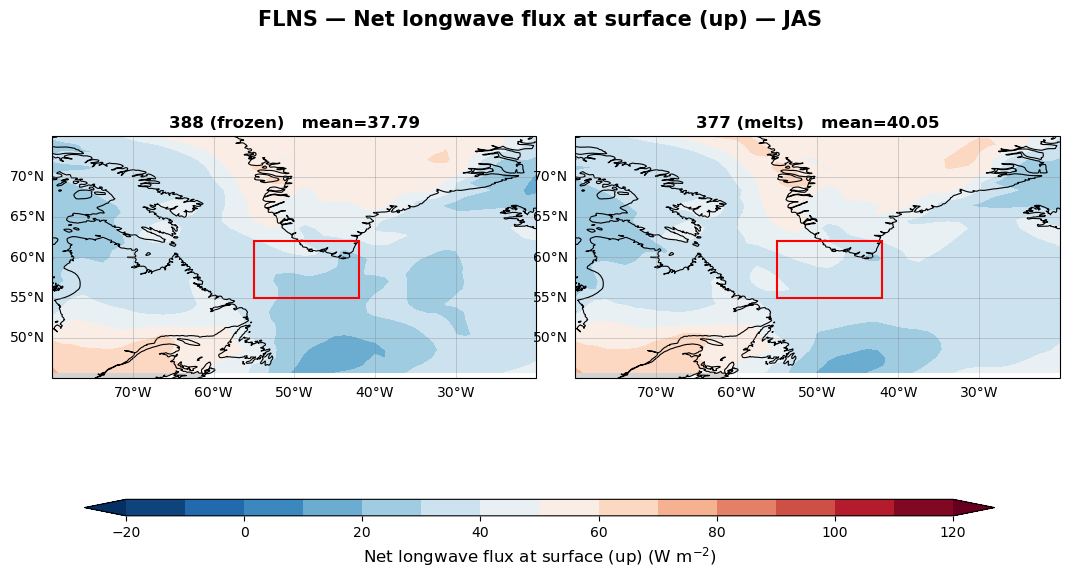

  saved ./figs/map_FSDS_JFM_LabSea.png


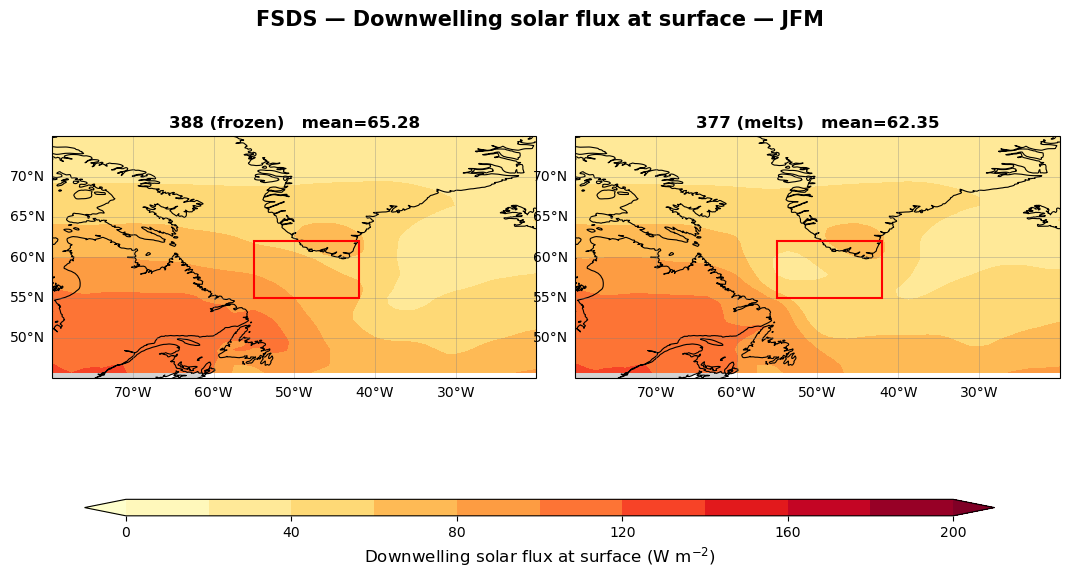

  saved ./figs/map_FSDS_JAS_LabSea.png


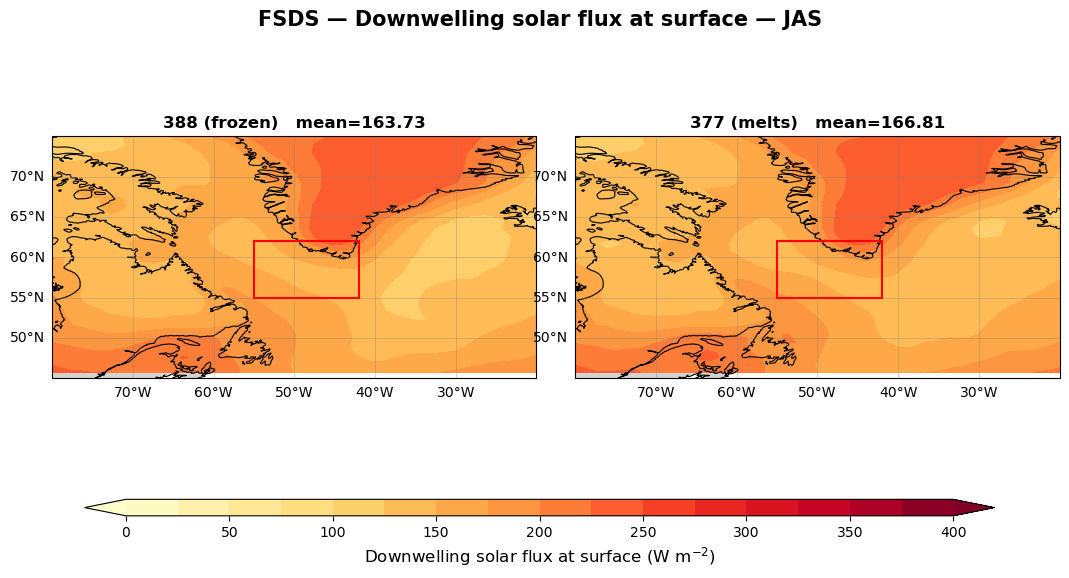

In [14]:
# Side-by-side maps, one figure per (variable, season).
# Red box overlays the SE Labrador Sea box used for the timeseries.
for var in VARS:
    for season in SEASONS:
        lsu.plot_pair_map(clim[(var, season)], var, season,
                          region="LabSea",
                          extra_box="LabSea_SE",
                          save_dir=FIG_DIR)
        plt.show()

The red rectangle marks the **SE Labrador Sea** box (`REGIONS['LabSea_SE']`) that the companion notebook uses for the seasonal timeseries.  Adjust its bounds in `labsea_utils.py` if it doesn't line up with the region of frozen surface in 388.